<a href="https://colab.research.google.com/github/karen-nakaoka/TelecomX/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [3]:
import pandas as pd

In [4]:
telecomx = pd.read_json('/content/TelecomX_Data.json')
telecomx

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformação

Nesta etapa foi realizada a exploração inicial do dataset da Telecom X, com o objetivo de compreender sua estrutura e as variáveis disponíveis. O conjunto de dados possui 7267 registros e 21 colunas, contendo informações demográficas dos clientes, serviços contratados, características de contrato e dados financeiros. A variável Churn indica se o cliente cancelou ou não o serviço e será utilizada como variável principal na análise de evasão.


**Variáveis mais relevantes para churn:**

**Tempo de contrato do cliente**
tenure

**Tipo de contrato**
Contract

**Serviços adicionais**
TechSupport /
OnlineSecurity /
InternetService

**Custos**
Charges.Monthly /
Charges.Total

**Perfil do cliente**
SeniorCitizen /
Partner /
Dependents

Também foi realizada a verificação de inconsistências e valores nulos e duplicados.
Foi identificado que a variável Charges.Total apresentava 11 valores nulos, correspondentes a clientes com tenure igual a 0 meses, indicando que ainda não haviam acumulado cobranças totais. Esses valores foram substituídos por 0.

Também foi verificado que não existem registros duplicados no dataset e que os tipos de dados estão adequados para análise após a conversão da variável Charges.Total para formato numérico.

In [5]:
customer = pd.json_normalize(telecomx['customer'])
phone = pd.json_normalize(telecomx['phone'])
internet = pd.json_normalize(telecomx['internet'])
account = pd.json_normalize(telecomx['account'])

In [6]:
telecomx = telecomx.drop(columns=['customer', 'phone', 'internet', 'account'])

In [7]:
telecomx = pd.concat([telecomx, customer, phone, internet, account], axis=1)

In [8]:
telecomx.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
telecomx.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [10]:
telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**Verificação de itens nulos**

**Alteração do tipo de Charges.Total para formato float**

In [11]:
telecomx['Charges.Total'] = pd.to_numeric(telecomx['Charges.Total'], errors='coerce')

In [12]:
telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**Verificação de itens duplicados**

In [13]:
telecomx.duplicated().sum()

np.int64(0)

**Verificação de itens nulos**

In [14]:
telecomx.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
telecomx[telecomx['Charges.Total'].isnull()][['tenure','Charges.Monthly','Charges.Total']]

,tenure,Charges.Monthly,Charges.Total
975,0,56.05,NaN
1775,0,20.00,NaN
1955,0,61.90,NaN
2075,0,19.70,NaN
2232,0,20.25,NaN
2308,0,25.35,NaN
2930,0,73.35,NaN
3134,0,25.75,NaN
3203,0,52.55,NaN
4169,0,80.85,NaN


**Tratamento dos itens nulos na coluna Charges.Total**

In [16]:
telecomx['Charges.Total'] = telecomx['Charges.Total'].fillna(0)

In [17]:
telecomx['Charges.Total'].isnull().sum()

np.int64(0)

**Verificação de inconsistências**

In [18]:
telecomx['Churn'].unique()
telecomx['Contract'].unique()
telecomx['InternetService'].unique()
telecomx['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

**Criação da nova coluna Contas_Diarias**

In [19]:
telecomx['Contas_Diarias'] = (telecomx['Charges.Monthly'] / 30).round(2)

In [20]:
telecomx.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


**Conversão de colunas de "Yes" e "No" em variáveis binárias**

In [21]:
colunas_binarias = [
    'Churn',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in colunas_binarias:
    telecomx[col] = telecomx[col].map({'No':0, 'Yes':1})

In [22]:
telecomx[colunas_binarias].head()

,Churn,Partner,Dependents,PhoneService,PaperlessBilling
0,0.0,1,1,1,1
1,0.0,0,0,1,0
2,1.0,0,0,1,1
3,1.0,1,0,1,1
4,1.0,1,0,1,1


In [23]:
telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**Renomeação das colunas**

In [24]:
telecomx = telecomx.rename(columns={
    'customerID': 'Cliente_id',
    'Churn': 'Evasão',
    'gender': 'Gênero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses de contrato',
    'PhoneService': 'Ass. de servico telefônico',
    'MultipleLines': 'Ass. de múltiplas linhas',
    'InternetService': 'Ass. de provedor internet',
    'OnlineSecurity': 'Ass. de segurança online',
    'OnlineBackup': 'Ass. de backup online',
    'DeviceProtection': 'Ass. de proteção no dispositivo',
    'TechSupport': 'Ass. de suporte técnico',
    'StreamingTV': 'Ass. de tv a cabo',
    'StreamingMovies': 'Ass. de streaming de filmes',
    'Contract': 'Tipo de contrato',
    'PaperlessBilling': 'Prefere fatura online',
    'PaymentMethod': 'Forma de pagamento',
    'Charges.Monthly': 'Gasto mensal',
    'Charges.Total': 'Gasto total',
    'Contas_Diarias': 'Gasto diário'
})

In [25]:
telecomx.columns

Index(['Cliente_id', 'Evasão', 'Gênero', 'Idoso', 'Parceiro', 'Dependentes',
       'Meses de contrato', 'Ass. de servico telefônico',
       'Ass. de múltiplas linhas', 'Ass. de provedor internet',
       'Ass. de segurança online', 'Ass. de backup online',
       'Ass. de proteção no dispositivo', 'Ass. de suporte técnico',
       'Ass. de tv a cabo', 'Ass. de streaming de filmes', 'Tipo de contrato',
       'Prefere fatura online', 'Forma de pagamento', 'Gasto mensal',
       'Gasto total', 'Gasto diário'],
      dtype='object')

#📊 Carga e análise

A análise descritiva das variáveis numéricas permitiu compreender melhor o comportamento financeiro e o tempo de permanência dos clientes. Observa-se que o tempo médio de contrato é de aproximadamente 32 meses, com clientes permanecendo na empresa por até 72 meses.

O gasto mensal médio é de 64,72, enquanto o gasto total médio é de 2277,18, apresentando grande variação entre os clientes, refletida no alto desvio padrão. Essa variação ocorre principalmente devido às diferenças no tempo de permanência dos clientes na empresa.

In [26]:
telecomx_analise = (telecomx[['Meses de contrato', 'Gasto mensal', 'Gasto total', 'Gasto diário']].describe()).round(2)
telecomx_analise

,Meses de contrato,Gasto mensal,Gasto total,Gasto diário
count,7267.00,7267.00,7267.00,7267.00
mean,32.35,64.72,2277.18,2.16
std,24.57,30.13,2268.65,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.42,396.20,1.18
50%,29.00,70.30,1389.20,2.34
75%,55.00,89.88,3778.52,3.00
max,72.00,118.75,8684.80,3.96


**Média**

In [27]:
telecomx_media = (telecomx[['Meses de contrato','Gasto mensal','Gasto total','Gasto diário']].mean()).round(2)
telecomx_media

,0
Meses de contrato,32.35
Gasto mensal,64.72
Gasto total,2277.18
Gasto diário,2.16


**Mediana**

In [28]:
telecomx_mediana = (telecomx[['Meses de contrato','Gasto mensal','Gasto total','Gasto diário']].median()).round(2)
telecomx_mediana

,0
Meses de contrato,29.00
Gasto mensal,70.30
Gasto total,1389.20
Gasto diário,2.34


**Desvio padrão**

In [29]:
telecomx_desvio_padrao = (telecomx[['Meses de contrato','Gasto mensal','Gasto total','Gasto diário']].std()).round(2)
telecomx_desvio_padrao

,0
Meses de contrato,24.57
Gasto mensal,30.13
Gasto total,2268.65
Gasto diário,1.00


**Distribuição da evasão**

O gráfico mostra a distribuição da variável telecomx_evasao, indicando a proporção de clientes que permaneceram na empresa em comparação com aqueles que cancelaram o serviço. Observa-se que aproximadamente 73,5% dos clientes permaneceram, enquanto 26,5% cancelaram o serviço.

In [36]:
telecomx_evasao = vasao = telecomx['Evasão'].value_counts()
telecomx_evasao

,count
Evasão,
0.0,5174
1.0,1869


In [42]:
telecomx_evasao_proporcao = telecomx['Evasão'].value_counts(normalize=True)*100
telecomx_evasao_proporcao

,proportion
Evasão,
0.0,73.463013
1.0,26.536987


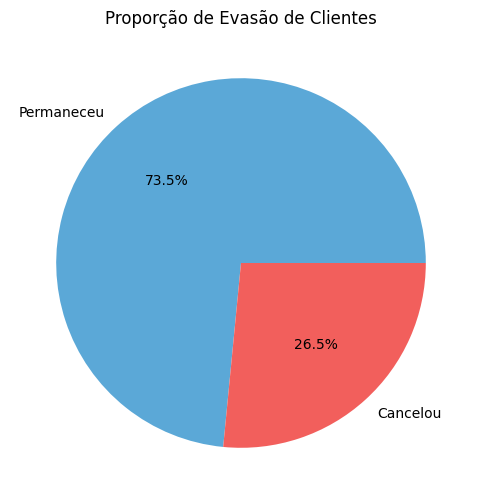

In [43]:
import matplotlib.pyplot as plt

evasao = telecomx['Evasão'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(telecomx_evasao,
        labels=['Permaneceu','Cancelou'],
        autopct='%1.1f%%',
        colors=['#5BA8D7','#F25F5C'])

plt.title('Proporção de Evasão de Clientes')

plt.show()

**Contagem de evasão por variáveis categóricas**

Os resultados indicam que o gênero não apresenta diferenças significativas na taxa de evasão.

A análise da evasão em relação ao tipo de contrato revela um padrão claro: clientes com contrato Month-to-month apresentam uma taxa de cancelamento significativamente maior (42,7%) em comparação com clientes com contratos de 1 ano (11,3%) ou 2 anos (2,8%). Isso sugere que contratos de maior duração estão associados a uma maior retenção de clientes.

Em relação ao método de pagamento, observa-se que clientes que utilizam Electronic check apresentam a maior taxa de evasão (45,3%), enquanto métodos automáticos como transferência bancária e cartão de crédito apresentam taxas significativamente menores. Esse padrão pode indicar que clientes que utilizam pagamentos automáticos tendem a permanecer mais tempo na empresa.

**Evasão por gênero**

In [44]:
evasao_genero = pd.crosstab(telecomx['Gênero'], telecomx['Evasão'])
evasao_genero

Evasão,0.0,1.0
Gênero,,
Female,2549,939
Male,2625,930


In [45]:
evasao_genero_proporcao = pd.crosstab(telecomx['Gênero'], telecomx['Evasão'], normalize='index')*100
evasao_genero_proporcao

Evasão,0.0,1.0
Gênero,,
Female,73.079128,26.920872
Male,73.839662,26.160338


**Evasão por tipo de contrato**

In [47]:
evasao_tipo_contrato = pd.crosstab(telecomx['Tipo de contrato'], telecomx['Evasão'])
evasao_tipo_contrato

Evasão,0.0,1.0
Tipo de contrato,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [48]:
evasao_tipo_contrato_proporcao = pd.crosstab(telecomx['Tipo de contrato'], telecomx['Evasão'], normalize='index')*100
evasao_tipo_contrato_proporcao

Evasão,0.0,1.0
Tipo de contrato,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


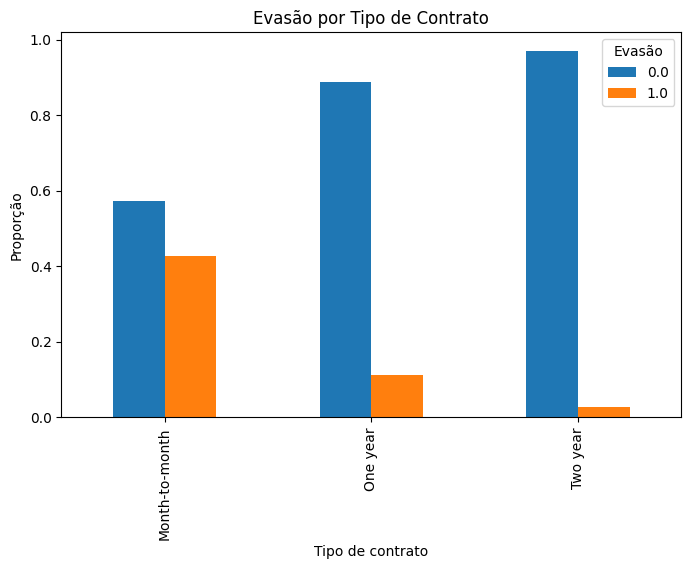

In [53]:
evasao_contrato = pd.crosstab(
    telecomx['Tipo de contrato'],
    telecomx['Evasão'],
    normalize='index'
)

evasao_contrato.plot(kind='bar', figsize=(8,5))

plt.title('Evasão por Tipo de Contrato')
plt.ylabel('Proporção')
plt.xlabel('Tipo de contrato')

plt.show()

**Evasão por método de pagamento**

In [50]:
evasao_metodo_pag = pd.crosstab(telecomx['Forma de pagamento'], telecomx['Evasão'])
evasao_metodo_pag

Evasão,0.0,1.0
Forma de pagamento,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [52]:
evasao_metodo_pag_proporcao = pd.crosstab(telecomx['Forma de pagamento'], telecomx['Evasão'], normalize='index')*100
evasao_metodo_pag_proporcao

Evasão,0.0,1.0
Forma de pagamento,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


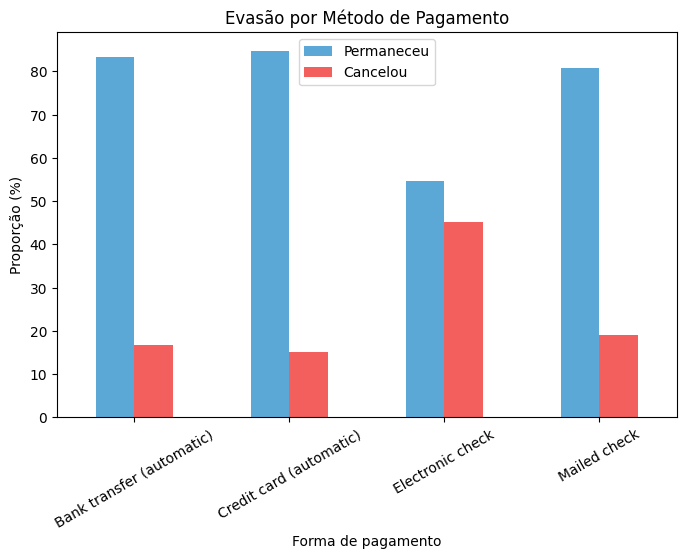

In [64]:
evasao_metodo_pag_proporcao.plot(
    kind='bar',
    figsize=(8,5),
    color=['#5BA8D7', '#F25F5C']
)

plt.title('Evasão por Método de Pagamento')
plt.xlabel('Forma de pagamento')
plt.ylabel('Proporção (%)')

plt.legend(['Permaneceu', 'Cancelou'])

plt.xticks(rotation=30)

plt.show()

**Contagem de evasão por variáveis numéricas**

Para facilitar a interpretação, os valores foram agrupados em faixas, permitindo observar como a proporção de cancelamentos varia entre diferentes níveis dessas variáveis.

Os resultados indicam que clientes com menor tempo de contrato apresentam maior taxa de evasão, enquanto clientes com maior tempo de permanência tendem a continuar no serviço. Também foi possível observar diferenças no comportamento de evasão de acordo com as faixas de gasto mensal, sugerindo que o valor pago pode influenciar na decisão de cancelamento.

**Evasão por meses de contrato**

In [54]:
telecomx['Faixa_tempo_contrato'] = pd.cut(
    telecomx['Meses de contrato'],
    bins=[0,12,24,48,72],
    labels=['0-12 meses','13-24 meses','25-48 meses','49-72 meses']
)

In [55]:
evasao_tempo = pd.crosstab(
    telecomx['Faixa_tempo_contrato'],
    telecomx['Evasão'],
    normalize='index'
) * 100

evasao_tempo

Evasão,0.0,1.0
Faixa_tempo_contrato,,
0-12 meses,52.321839,47.678161
13-24 meses,71.289062,28.710938
25-48 meses,79.611041,20.388959
49-72 meses,90.486824,9.513176


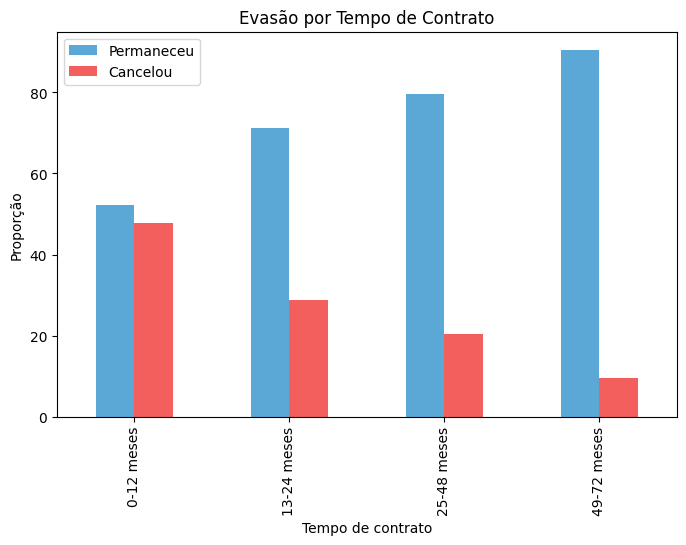

In [56]:
evasao_tempo.plot(kind='bar', figsize=(8,5), color=['#5BA8D7','#F25F5C'])

plt.title('Evasão por Tempo de Contrato')
plt.xlabel('Tempo de contrato')
plt.ylabel('Proporção')

plt.legend(['Permaneceu','Cancelou'])

plt.show()

In [59]:
telecomx.groupby('Evasão')[[
    'Meses de contrato',
    'Gasto mensal',
    'Gasto total',
    'Gasto diário'
]].mean().round(2)

,Meses de contrato,Gasto mensal,Gasto total,Gasto diário
Evasão,,,,
0.0,37.57,61.27,2549.91,2.04
1.0,17.98,74.44,1531.80,2.48


**Evasão por gasto mensal**

In [60]:
telecomx['Faixa_gasto_mensal'] = pd.cut(
    telecomx['Gasto mensal'],
    bins=[0,40,70,100,120],
    labels=['0-40','40-70','70-100','100+']
)

In [61]:
evasao_gasto = pd.crosstab(
    telecomx['Faixa_gasto_mensal'],
    telecomx['Evasão'],
    normalize='index'
) * 100

evasao_gasto

Evasão,0.0,1.0
Faixa_gasto_mensal,,
0-40,88.356910,11.643090
40-70,76.078915,23.921085
70-100,62.178292,37.821708
100+,71.951220,28.048780


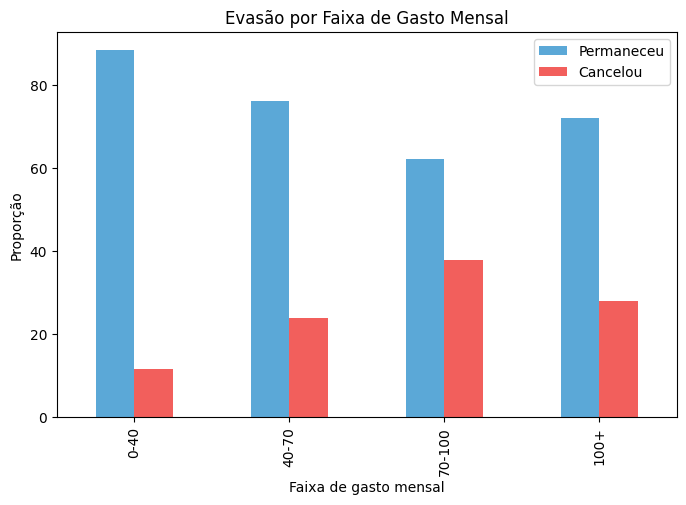

In [62]:
evasao_gasto.plot(kind='bar', figsize=(8,5), color=['#5BA8D7','#F25F5C'])

plt.title('Evasão por Faixa de Gasto Mensal')
plt.xlabel('Faixa de gasto mensal')
plt.ylabel('Proporção')

plt.legend(['Permaneceu','Cancelou'])

plt.show()

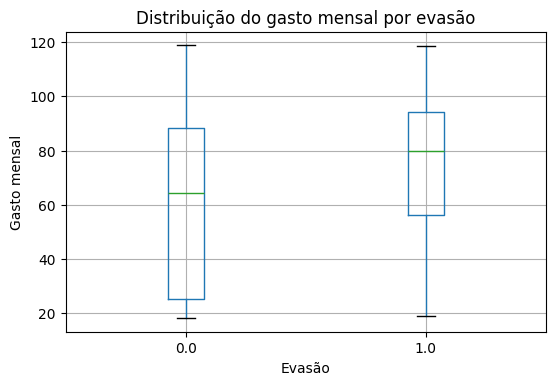

In [63]:
telecomx.boxplot(column='Gasto mensal', by='Evasão', figsize=(6,4))

plt.title('Distribuição do gasto mensal por evasão')
plt.suptitle('')
plt.xlabel('Evasão')
plt.ylabel('Gasto mensal')

plt.show()

#Extra: Correlação entre variáveis

In [65]:
correlacao = telecomx[['Idoso',
                       'Meses de contrato',
                       'Gasto mensal',
                       'Gasto total',
                       'Gasto diário',
                       'Evasão']].corr()

correlacao

,Idoso,Meses de contrato,Gasto mensal,Gasto total,Gasto diário,Evasão
Idoso,1.000000,0.018187,0.220388,0.104076,0.220360,0.150889
Meses de contrato,0.018187,1.000000,0.247982,0.825407,0.247992,-0.352229
Gasto mensal,0.220388,0.247982,1.000000,0.652211,0.999996,0.193356
Gasto total,0.104076,0.825407,0.652211,1.000000,0.652225,-0.198324
Gasto diário,0.220360,0.247992,0.999996,0.652225,1.000000,0.193412
Evasão,0.150889,-0.352229,0.193356,-0.198324,0.193412,1.000000


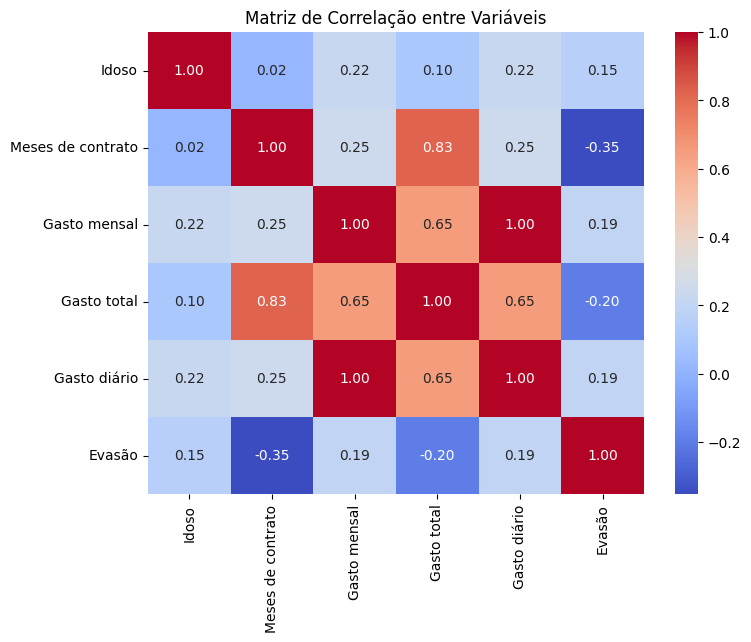

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação entre Variáveis')
plt.show()

#📄Relatorio Final

# 1. Introdução

A evasão de clientes, também conhecida como churn, representa um dos principais desafios enfrentados por empresas de telecomunicações. A perda de clientes impacta diretamente a receita e pode indicar problemas relacionados à experiência do usuário, competitividade do mercado ou estrutura de preços.

O objetivo desta análise é identificar padrões e fatores associados ao cancelamento de serviços na empresa Telecom X. Para isso, foram aplicadas técnicas de extração, tratamento e análise exploratória de dados (EDA) utilizando Python e bibliotecas como Pandas e Matplotlib.

A análise busca compreender o comportamento dos clientes e identificar características que possam estar relacionadas a uma maior probabilidade de evasão, fornecendo insights que possam auxiliar futuras estratégias de retenção.

# 2. Extração, Limpeza e Tratamento de Dados

Os dados utilizados neste projeto foram obtidos a partir de uma API, sendo posteriormente carregados em um DataFrame utilizando a biblioteca Pandas.

Inicialmente, algumas colunas estavam estruturadas em formato aninhado (nested) dentro do JSON. Essas colunas foram normalizadas para que cada atributo fosse transformado em uma coluna independente, facilitando a análise.

Após a estruturação inicial, foram realizadas verificações para garantir a qualidade dos dados:

- Verificação de tipos de dados

- Identificação de valores ausentes

- Verificação de duplicatas

- Análise de inconsistências nas categorias

Durante essa etapa, foram identificados 11 valores ausentes na coluna "Gasto total". Ao analisar esses registros, foi observado que todos correspondem a clientes com tempo de contrato igual a zero, indicando clientes recém-ingressados no serviço, que ainda não acumularam gastos totais.

Também foi criada uma nova variável chamada "Gasto diário", calculada a partir do valor do gasto mensal, com o objetivo de permitir análises adicionais sobre o comportamento de consumo dos clientes.

Além disso, algumas colunas foram renomeadas para português, tornando o dataset mais claro e interpretável durante a análise.

# 3. Análise Exploratória de Dados (EDA)

A análise exploratória teve como objetivo identificar padrões, tendências e possíveis relações entre as características dos clientes e a evasão.

# 3.1 Distribuição Geral da Evasão

O primeiro passo foi analisar a proporção geral de clientes que cancelaram o serviço em comparação com aqueles que permaneceram.

**Gráfico: Proporção de evasão de clientes**

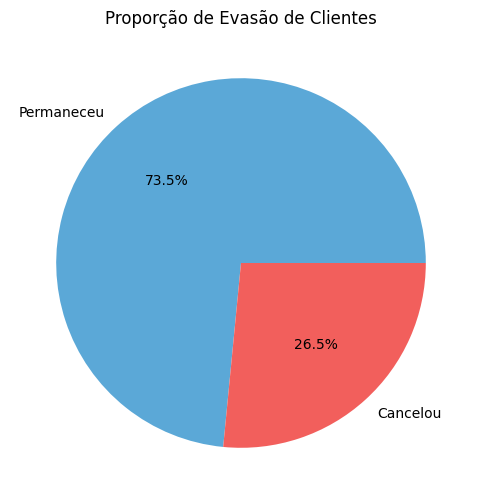

A análise mostrou que aproximadamente 73,5% dos clientes permaneceram, enquanto 26,5% cancelaram o serviço. Esse resultado indica que, embora a maioria dos clientes permaneça na empresa, existe uma parcela significativa de cancelamentos que merece atenção.

# 3.2 Evasão por Variáveis Categóricas

Em seguida, foram analisadas algumas variáveis categóricas que podem influenciar o comportamento dos clientes, como:

- Gênero

- Tipo de contrato

- Forma de pagamento

**Gráfico: Evasão por tipo de contrato**

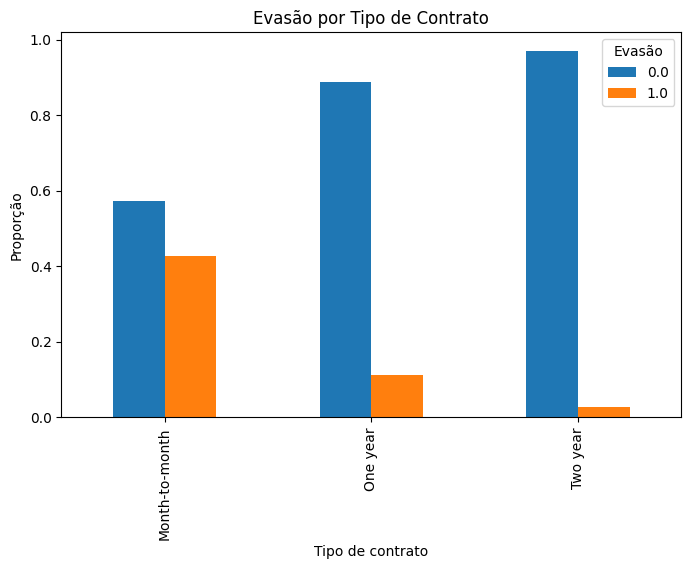

A análise revelou que clientes com contratos mensais (month-to-month) apresentam uma taxa significativamente maior de evasão quando comparados a clientes com contratos de um ou dois anos.

Isso sugere que contratos de maior duração podem estar associados a maior fidelização dos clientes.

**Gráfico: Evasão por método de pagamento**

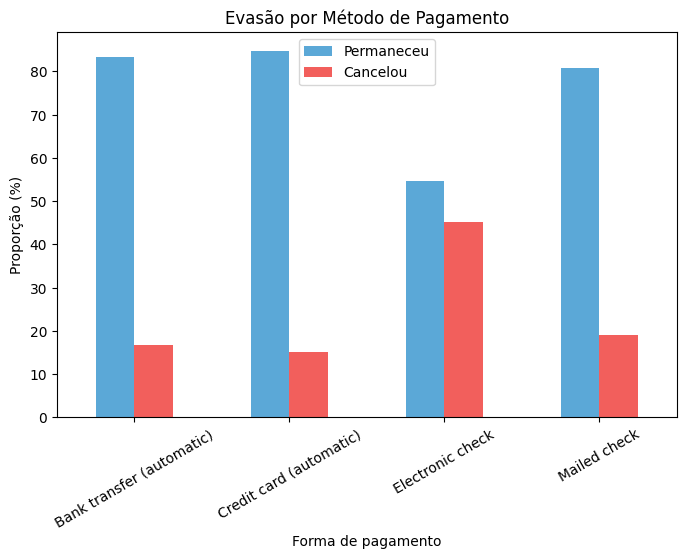

Observou-se que clientes que utilizam Electronic Check como forma de pagamento apresentam uma proporção de cancelamento consideravelmente maior em relação aos demais métodos de pagamento.

Esse comportamento pode indicar que determinados perfis de clientes ou formas de pagamento estão associados a maior risco de evasão.

# 3.3 Evasão por Variáveis Numéricas

Além das variáveis categóricas, também foram analisadas variáveis numéricas relevantes, como:

- Tempo de contrato (tenure)

- Gasto mensal

- Gasto total

Essas variáveis ajudam a entender o comportamento financeiro e o tempo de relacionamento dos clientes com a empresa.

**Gráfico: Evasão por tempo de contrato**

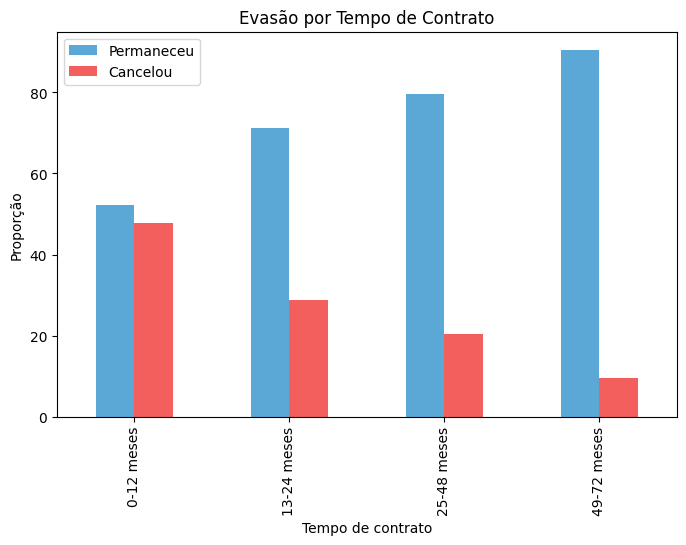

A análise mostrou que clientes com menor tempo de contrato apresentam maior taxa de evasão, especialmente nos primeiros meses de relacionamento com a empresa.

À medida que o tempo de contrato aumenta, observa-se uma redução significativa na proporção de cancelamentos, indicando maior fidelização ao longo do tempo.


**Gráfico: Evasão por faixa de gasto mensal**

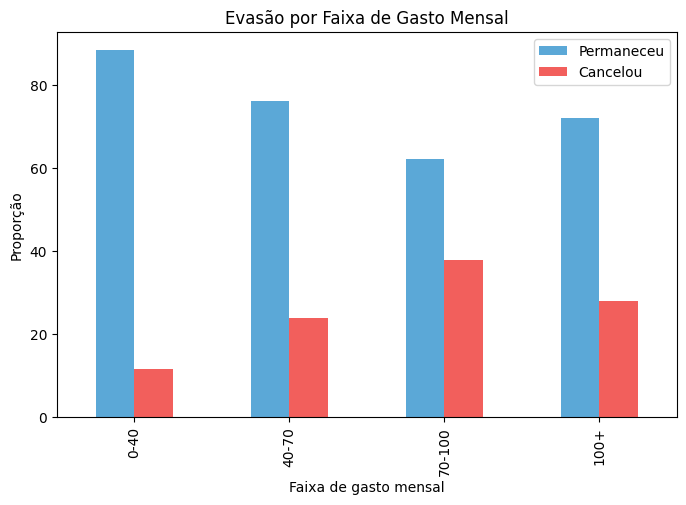

A análise por faixas de gasto mensal indica diferenças no comportamento de evasão entre clientes com diferentes níveis de consumo.

Clientes em determinadas faixas de gasto apresentam maior tendência ao cancelamento, sugerindo que o valor pago pelos serviços pode influenciar a decisão de permanecer ou cancelar o contrato.

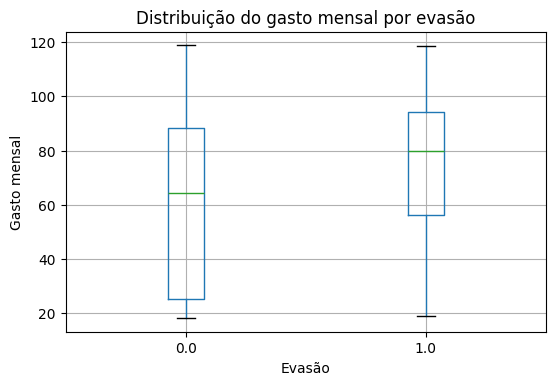

A distribuição do gasto mensal entre clientes que permaneceram e clientes que cancelaram o serviço foi analisada utilizando um boxplot, que permite visualizar a mediana, a dispersão e possíveis valores extremos.

Observa-se que clientes que cancelaram o serviço tendem a apresentar gastos mensais mais elevados, com uma mediana superior em comparação aos clientes que permaneceram. Além disso, a distribuição dos valores indica que clientes com planos mais caros apresentam maior propensão à evasão.

Esse padrão pode indicar que custos mais elevados podem influenciar a decisão de cancelamento, sugerindo que estratégias de retenção podem ser especialmente importantes para clientes com maiores valores de mensalidade.

# Extra: Correlação entre variáveis

Como etapa adicional, foi realizada uma análise de correlação entre algumas variáveis numéricas do dataset, com o objetivo de identificar possíveis relações entre características dos clientes e a evasão.

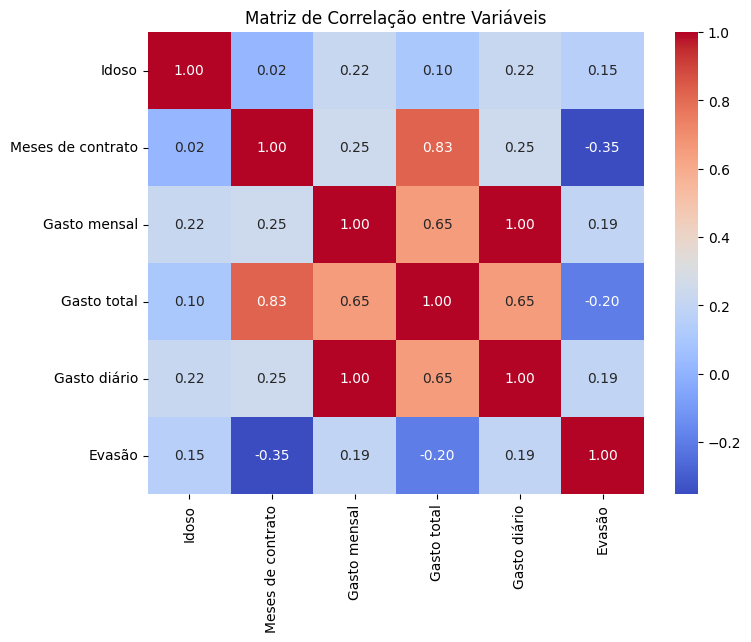

A matriz de correlação mostra que o tempo de contrato apresenta correlação negativa com a evasão (-0,35), indicando que clientes com maior tempo de permanência na empresa tendem a cancelar menos o serviço. Esse resultado reforça o padrão observado nas análises anteriores, onde clientes mais antigos apresentam maior probabilidade de permanecer na empresa.

Também foi possível observar correlações positivas entre algumas variáveis relacionadas a gastos, como gasto mensal, gasto diário e gasto total, o que é esperado, já que essas variáveis representam diferentes formas de medir o valor pago pelos clientes.

De modo geral, a análise sugere que o tempo de relacionamento do cliente com a empresa é um dos fatores mais relevantes associados à evasão, enquanto as variáveis de gasto apresentam relações mais moderadas com o cancelamento.

Essa análise complementa a exploração dos dados e pode auxiliar em futuras etapas de modelagem preditiva para identificação de clientes com maior risco de churn.

# 4. Conclusões e Insights

A análise exploratória permitiu identificar alguns padrões importantes associados à evasão de clientes na Telecom X.

Os principais insights encontrados foram:

- Clientes com contratos mensais apresentam maior probabilidade de cancelamento.

- Clientes com menor tempo de permanência na empresa apresentam maior taxa de evasão.

- O método de pagamento Electronic Check está associado a uma maior proporção de cancelamentos.

- Clientes que permanecem por mais tempo tendem a manter o serviço de forma mais estável.

Esses resultados indicam que fatores como **tipo de contrato, tempo de relacionamento e forma de pagamento** podem influenciar diretamente o comportamento de evasão.

# 5. Recomendações

Com base nos padrões identificados na análise, algumas ações podem ser consideradas para reduzir a evasão de clientes:

- Criar incentivos para que clientes com contratos mensais migrem para contratos mais longos, aumentando a fidelização.

- Desenvolver estratégias de retenção voltadas para clientes recém-adquiridos, especialmente nos primeiros meses de contrato.

- Avaliar possíveis melhorias no processo de pagamento ou na experiência dos clientes que utilizam Electronic Check.

- Implementar programas de fidelização ou benefícios progressivos para clientes com maior tempo de permanência.

Essas ações podem contribuir para reduzir a taxa de cancelamento e fortalecer o relacionamento com os clientes.